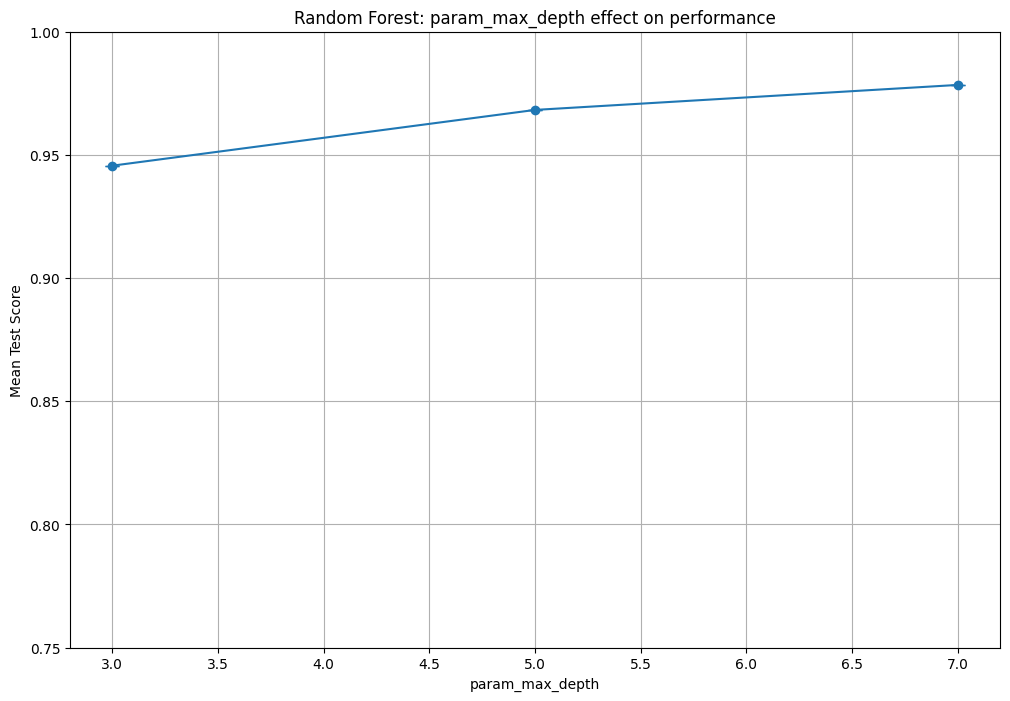

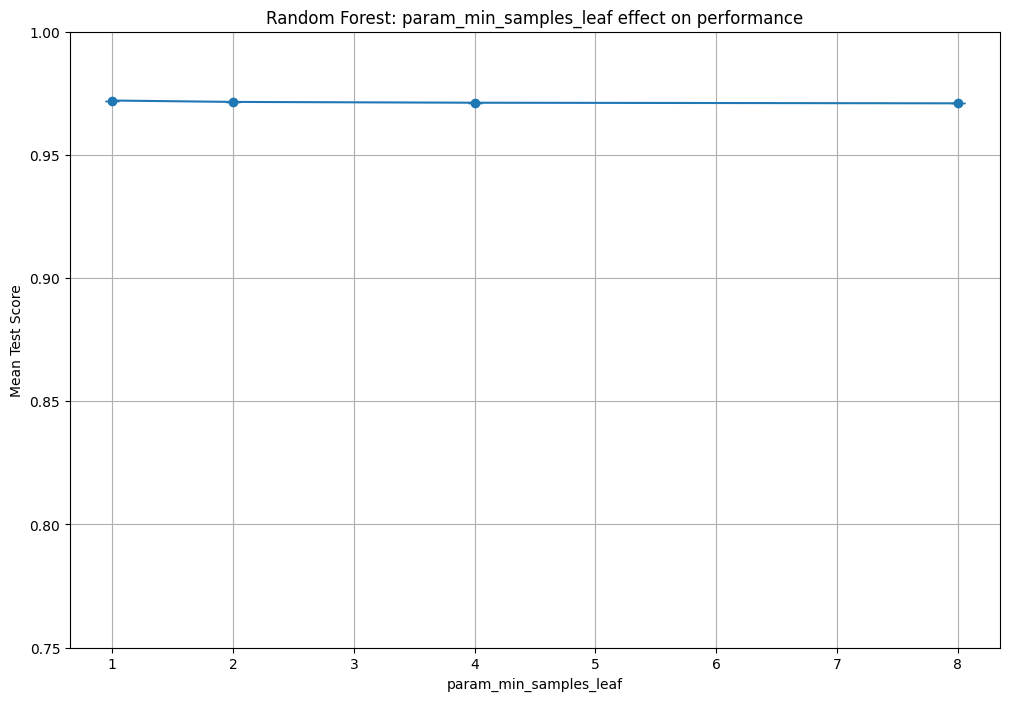

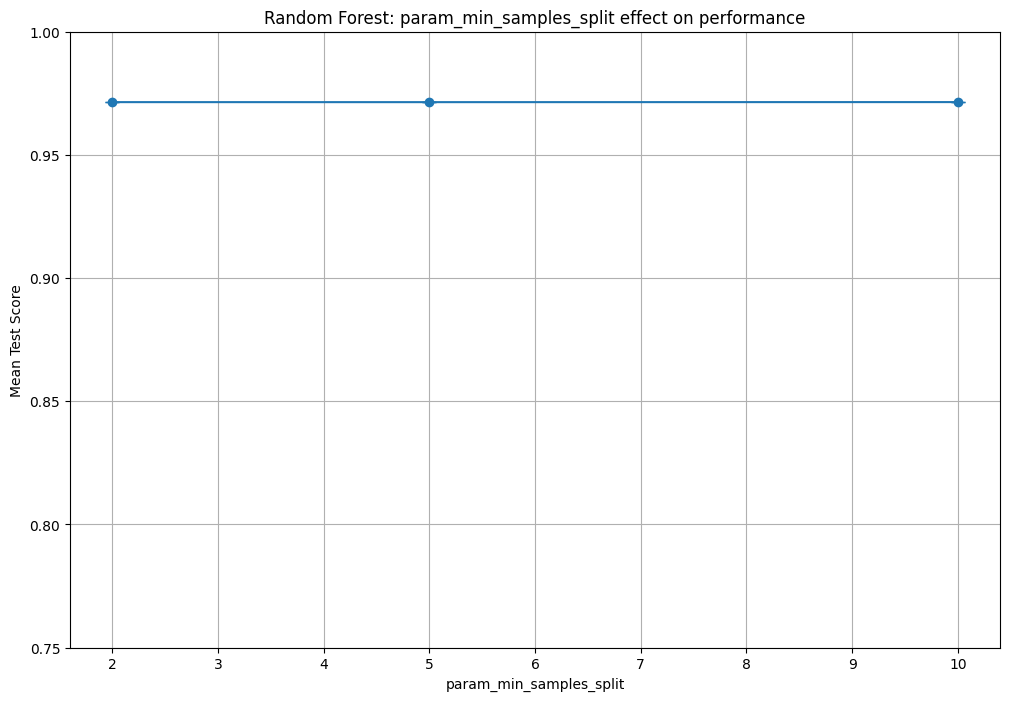

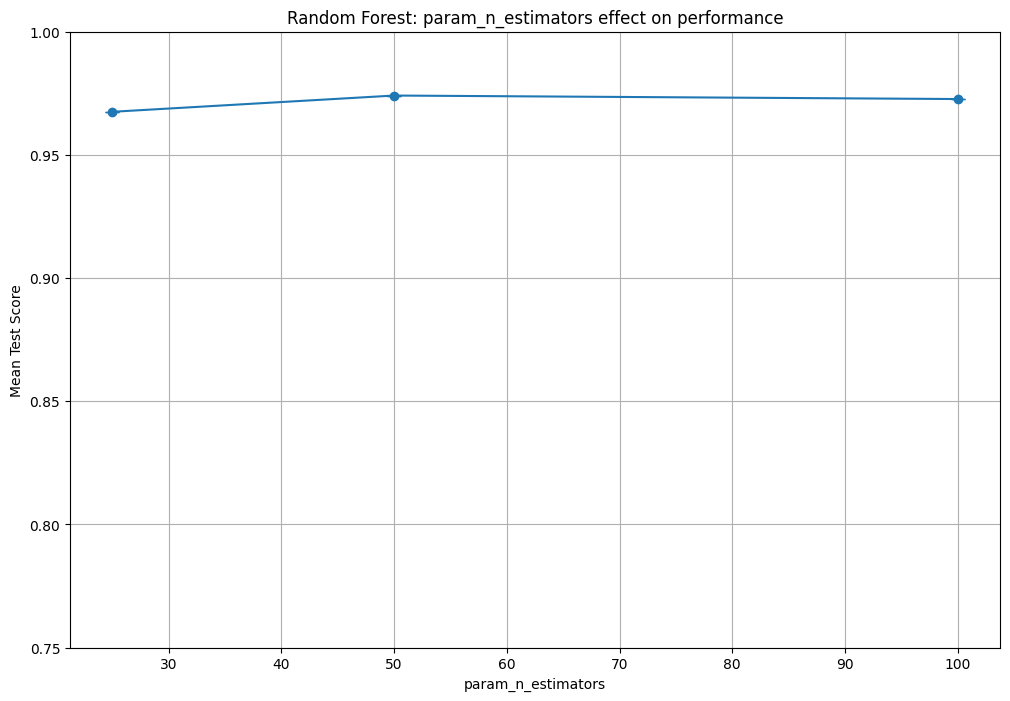

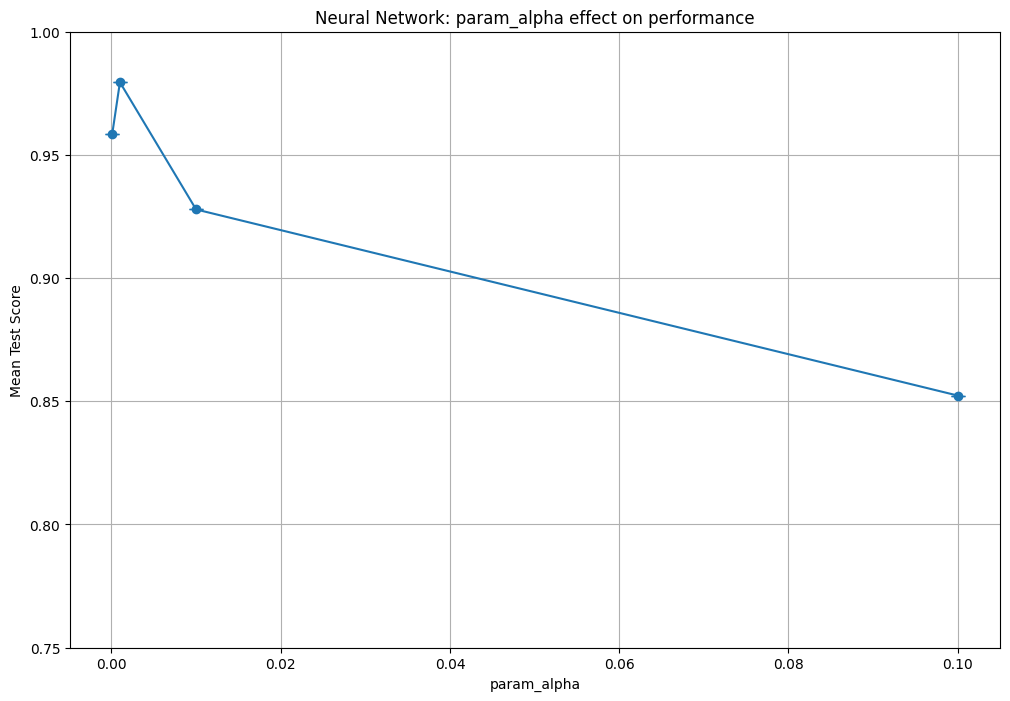

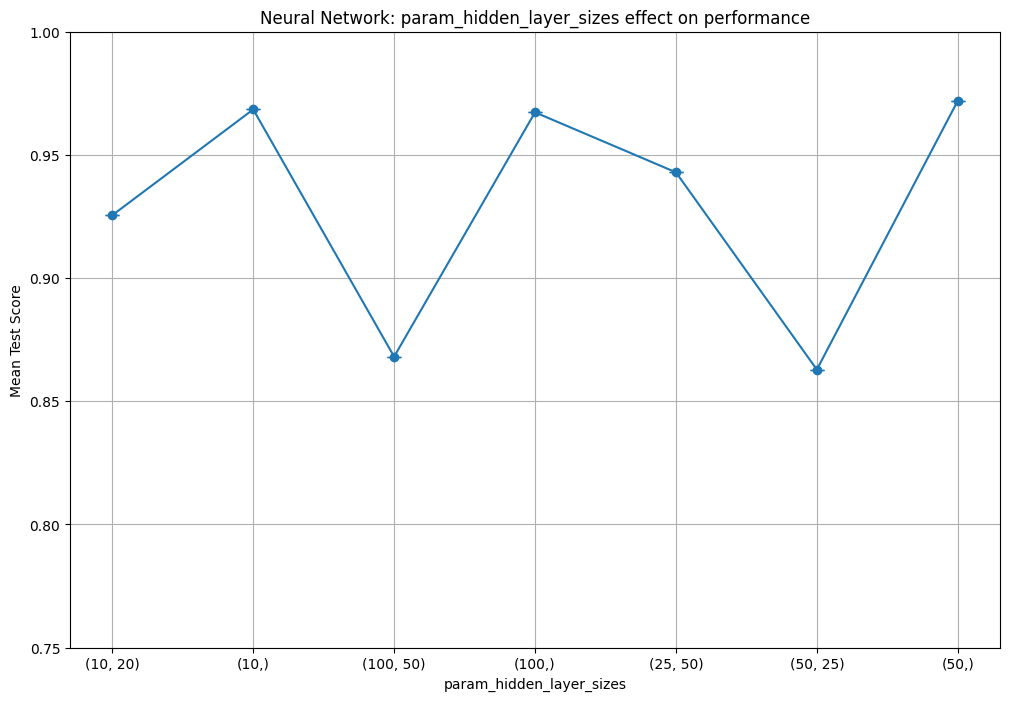

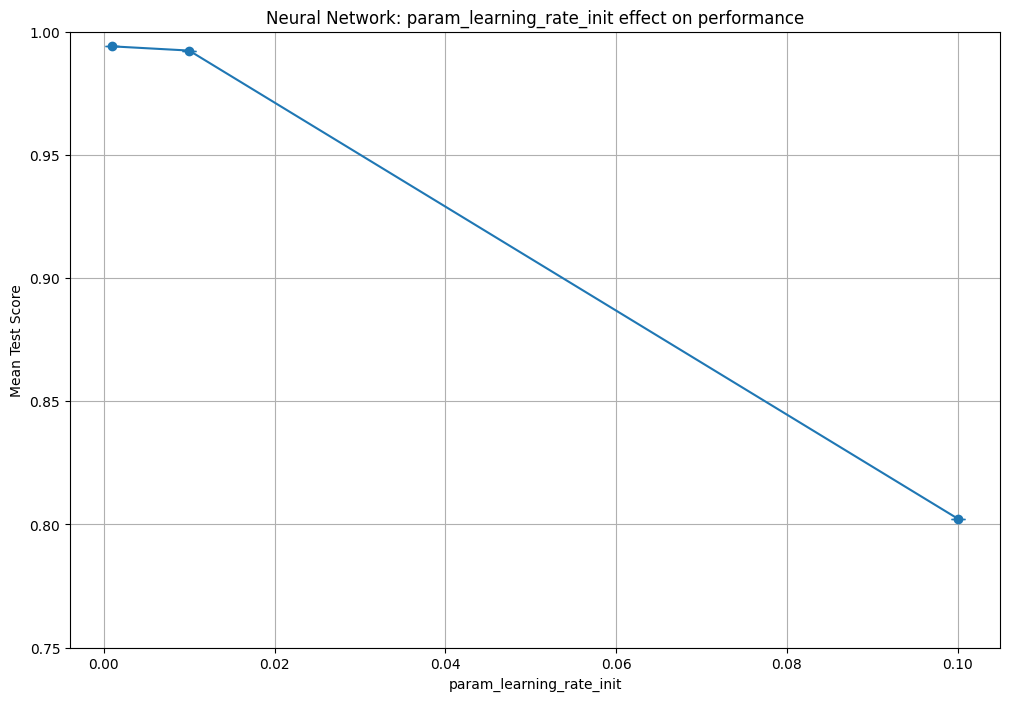

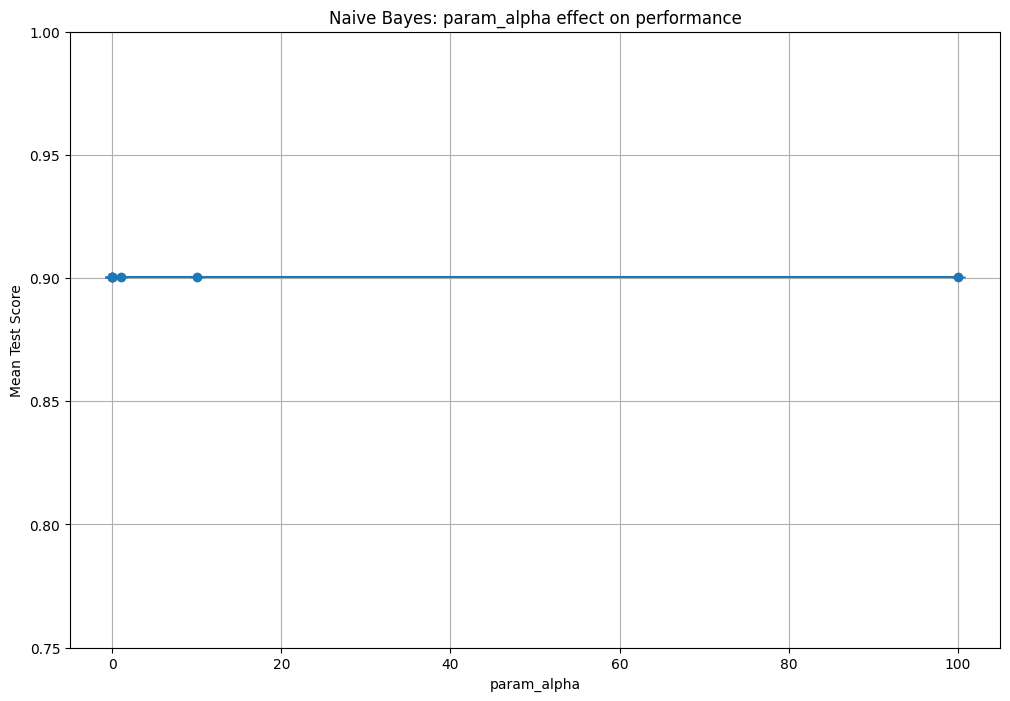

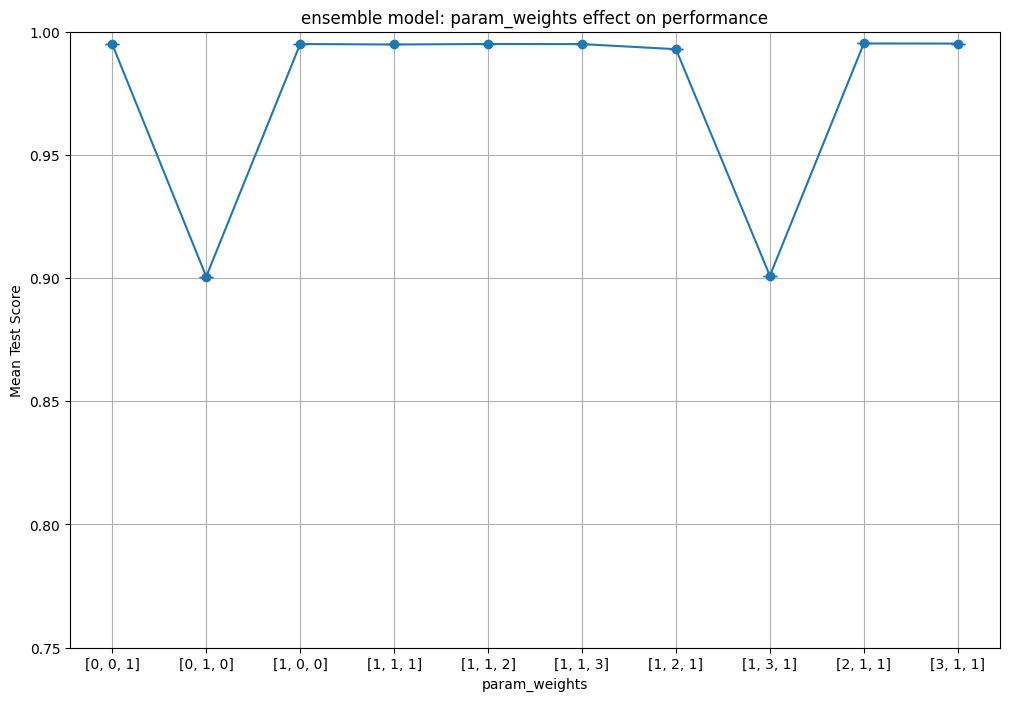

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, precision_recall_fscore_support, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder

from baseline_model import baseline_model
from decision_tree_full import decision_tree_with_gridsearch
from models import PHISURL_NaiveBayes, PHISURL_NeuralNetwork, PHISURL_RandomForest
from utils import plot_confusion_matrix
from input_to_test import preprocess_single_url

DROP_COLS = ["FILENAME", "URL", "Domain", "Title"]

def fn_focused_scorer(y_true, y_pred, fn_weight=5.0, fp_weight=1.0):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return (fn_weight * recall + fp_weight * specificity) / (fn_weight + fp_weight)


def run_gridsearch(model, param_grid, X_train, y_train, X_test, y_test, model_name):
    print(f"Running grid search for {model_name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=make_scorer(fn_focused_scorer),
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)


    y_pred = grid.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    print(f"{model_name} - Best params: {grid.best_params_}")
    print(f"{model_name} - CV Best Score: {grid.best_score_:.4f}")
    print(f"{model_name} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    results_df = pd.DataFrame(grid.cv_results_)
    results_df["model"] = model_name

    return grid.best_estimator_, results_df


def plot_hyperparam_results(all_results, param_name, score_name="mean_test_score"):
    plt.figure(figsize=(10, 6))
    plot_data = all_results.copy()

    # this part is a bit annoying
    if param_name == "param_hidden_layer_sizes":
        plot_data = plot_data[plot_data["model"] == "Neural Network"].copy()
        plot_data[param_name] = plot_data[param_name].apply(
            lambda x: (
                str(x).replace("(", "").replace(")", "").replace(",", "-")
                if pd.notna(x)
                else x
            )
        )

        sns.pointplot(
            data=plot_data,
            x=param_name,
            y=score_name,
            order=sorted(plot_data[param_name].unique()),
            color="blue",
            markers="o",
            linestyles="--",
        )
        plt.title(
            f"Neural Network: Hidden Layer Sizes vs {score_name}",
            fontsize=14,
            weight="bold",
        )

    else:
        sns.lineplot(
            data=plot_data,
            x=param_name,
            y=score_name,
            hue="model",
            marker="o",
            linewidth=2,
            alpha=0.85,
        )
        plt.title(
            f"Hyperparameter: {param_name} vs {score_name}", fontsize=14, weight="bold"
        )

    plt.xlabel(param_name, fontsize=12)
    plt.ylabel("Cross-validated Score", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.grid(True, linestyle="--", alpha=0.7)
    sns.despine()
    plt.legend(title="Model", fontsize=10, title_fontsize=11, frameon=False)
    plt.tight_layout()
    plt.show()


def extract_tld_features(df):
    tld_freq = df["TLD"].value_counts(normalize=True)
    df["TLDFrequency"] = df["TLD"].map(tld_freq).fillna(0)
    return df

def main():
    pure_data_set = pd.read_csv("../dataset/PhiUSIIL_Phishing_URL_Dataset.csv")
    pure_data_set = pure_data_set.drop(columns=DROP_COLS)
    pure_data_set["label"] = pure_data_set["label"].map({0: 1, 1: 0})  # Phishing=1, Safe=0

    X = pure_data_set.drop("label", axis=1)
    y = pure_data_set["label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    baseline_model(X_train, y_train)
    decision_tree_with_gridsearch(X_train, y_train)

    # Constrain features
    features = [
        "TLDFrequency","TLDLength", "URLLength", "IsDomainIP", "NoOfSubDomain",
        "IsHTTPS","NoOfDegitsInURL", "NoOfEqualsInURL", "NoOfQMarkInURL",
        "NoOfAmpersandInURL", "NoOfOtherSpecialCharsInURL", "DomainLength"
    ]
    X = extract_tld_features(X)
    X_constrained = X[features]
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_constrained, y, test_size=0.2, random_state=42)

    rf_model = PHISURL_RandomForest()
    nn_model = PHISURL_NeuralNetwork()
    nb_model = PHISURL_NaiveBayes()

    rf_best, nn_best, nb_best, all_results = main_hyperparam_reporting(
        X_train_c, y_train_c, X_test_c, y_test_c, rf_model, nn_model, nb_model
    )

    df = pd.read_csv("../results/all_model_gridsearch_results.csv")

    # Random forest
    plot_model_params(
        df, "Random Forest",
        ["param_max_depth", "param_min_samples_leaf", "param_min_samples_split", "param_n_estimators"]
    )

    # Neural Network
    plot_model_params(
        df, "Neural Network",
        ["param_alpha", "param_hidden_layer_sizes", "param_learning_rate_init"]
    )

    # Naive Bayes
    plot_model_params(
        df, "Naive Bayes",
        ["param_alpha"]
    )

    best_models = {"rf": rf_best, "nn": nn_best, "nb": nb_best}
    
    ensemble = VotingClassifier(
        estimators=[
            ("nn", best_models["nn"]),
            ("nb", best_models["nb"]),
            ("rf", best_models["rf"]),
        ],
        voting="soft"
    )

    param_grid = {
        "weights": [
            [1,1,1], [2,1,1], [1,2,1], [1,1,2],
            [3,1,1], [1,3,1], [1,1,3],
            [1,0,0], [0,1,0], [0,0,1]
        ]
    }

    best_ensemble, ensemble_results = run_gridsearch(ensemble, param_grid, X_train_c, y_train_c, X_test_c, y_test_c, "ensemble model")
    results = pd.DataFrame(ensemble_results)
    results.to_csv("../results/ensemble_gridsearch_results.csv", index=False)

    df = pd.read_csv("../results/ensemble_gridsearch_results.csv")

    plot_model_params(df, "ensemble model", ["param_weights"])
    

# Refactored hyperparameter reporting
def main_hyperparam_reporting(X_train, y_train, X_test, y_test, rf_model, nn_model, nb_model):
    rf_param_grid = {
        "n_estimators": [25, 50, 100],
        "max_depth": [3, 5, 7, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8]
    }

    nn_param_grid = {
        "hidden_layer_sizes": [(10,), (10,20), (25,50), (50,), (50,25), (100,), (100,50)],
        "alpha": [0.0001, 0.001, 0.01, 0.1],
        "learning_rate_init": [0.001, 0.01, 0.1]
    }

    nb_param_grid = {"alpha": [1e-8, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0]}

    rf_best, rf_results = run_gridsearch(rf_model, rf_param_grid, X_train, y_train, X_test, y_test, "Random Forest")
    nn_best, nn_results = run_gridsearch(nn_model, nn_param_grid, X_train, y_train, X_test, y_test, "Neural Network")
    nb_best, nb_results = run_gridsearch(nb_model, nb_param_grid, X_train, y_train, X_test, y_test, "Naive Bayes")

    all_results = pd.concat([rf_results, nn_results, nb_results], ignore_index=True)
    all_results.to_csv("../results/all_model_gridsearch_results.csv", index=False)

    return rf_best, nn_best, nb_best, all_results


def plot_model_params(df, model_name, params):
    """Plot given parameters vs mean test score for a model."""
    model_df = df[df["model"] == model_name]
    for param in params:
        if param in model_df.columns:
            grouped = (
                model_df.groupby(param)["mean_test_score"].agg(["mean", "std"]).reset_index()
            )
            plt.figure(figsize=(12,8))
            plt.errorbar(grouped[param], grouped["mean"], yerr=0, fmt="-o", capsize=5)
            plt.title(f"{model_name}: {param} effect on performance")
            plt.xlabel(param)
            plt.ylabel("Mean Test Score")
            plt.ylim([0.75, 1.0])
            plt.grid(True)
            plt.show()


if __name__ == "__main__":
    main()